# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Icha Aulia Putri
- **Email:** ichaaulia@gmail.com
- **ID Dicoding:** ichaaulia006

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (*weathersit*) terhadap jumlah rata-rata penyewaan sepeda harian selama tahun 2012?
- **Pertanyaan 2:** Pada jam berapa terjadi puncak penyewaan sepeda oleh pengguna *registered* pada hari kerja (*workingday*) selama tahun 2011?
- ...

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [ ]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama data harian untuk memastikan sudah masuk
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Tipe Data Tidak Sesuai: Kolom dteday pada day_df maupun hour_df masih bertipe object. Seharusnya kolom ini bertipe datetime agar kita bisa melakukan analisis berbasis waktu (tren bulanan atau harian) dengan benar.

- Kualitas Data (Kebersihan): Tidak ditemukan adanya missing values (data kosong) maupun data duplikat pada kedua dataset, sehingga data ini tergolong cukup bersih untuk dianalisis lebih lanjut.

- Representasi Kategorikal: Beberapa kolom seperti season, weathersit, mnth, dan weekday masih berupa angka (integer). Untuk mempermudah proses visualisasi dan pembacaan grafik nantinya, kolom-kolom ini sebaiknya diubah menjadi label kategori (misal: 1 menjadi 'Spring', 2 menjadi 'Summer', dst).

- Rentang Statistik: Nilai pada kolom temp, atemp, hum, dan windspeed sudah dalam bentuk ternormalisasi (skala 0 hingga 1). Ini adalah informasi penting jika nantinya kita ingin melakukan pemodelan statistik yang lebih lanjut.


### Assessing Data

#### Identifying ... problem

In [ ]:
# Memeriksa tipe data dan missing values pada day_df
print("--- Info day_df ---")
day_df.info()

# Memeriksa jumlah duplikat pada day_df
print("\nJumlah duplikat day_df:", day_df.duplicated().sum())

# Memeriksa statistik deskriptif day_df (untuk melihat keanehan angka)
print("\nStatistik deskriptif day_df:")
display(day_df.describe())

print("\n" + "="*30 + "\n")

# Memeriksa tipe data dan missing values pada hour_df
print("--- Info hour_df ---")
hour_df.info()

# Memeriksa jumlah duplikat pada hour_df
print("\nJumlah duplikat hour_df:", hour_df.duplicated().sum())

--- Info day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah duplikat day_df: 0

Statistik deskriptif day_df:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000




--- Info hour_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Jumlah duplikat hour_df: 

**Steps to Take:**
- Mengonversi tipe data kolom dteday menjadi datetime.

- Melakukan mapping atau mengubah angka pada kolom season dan weathersit menjadi keterangan teks agar lebih informatif.

- Memastikan tidak ada outlier yang ekstrem pada kolom jumlah penyewaan (cnt).

**Insight:** (Opsional)
- Masalah Tipe Data: Ditemukan bahwa kolom dteday pada kedua dataset (day_df dan hour_df) bertipe object. Ini akan menghambat proses analisis tren waktu jika tidak segera diubah menjadi tipe datetime.

- Representasi Kategorikal: Kolom musim (season) dan kondisi cuaca (weathersit) masih dalam bentuk numerik. Hal ini berpotensi membingungkan pembaca saat proses visualisasi data jika tidak dilakukan pemetaan (mapping) ke label teks yang sesuai.

- Kualitas Data: Secara keseluruhan, dataset ini sangat solid karena tidak memiliki nilai yang hilang (missing values) maupun data ganda (duplicate data), sehingga proses pembersihan akan lebih fokus pada penyesuaian format.

- Normalisasi Data: Nilai suhu, kelembapan, dan kecepatan angin sudah dalam bentuk ternormalisasi, yang memudahkan dalam pembacaan distribusi data tanpa perlu pengolahan skala tambahan.

### Cleaning Data

#### Fixing ... problem

In [ ]:
# 1. Mengubah tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mengubah angka menjadi keterangan label (Mapping)
# Agar saat visualisasi nanti, labelnya muncul 'Spring' bukan angka 1
day_df['season'] = day_df.season.map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})
day_df['weathersit'] = day_df.weathersit.map({
    1: 'Clear', 2: 'Misty', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice Pallets'
})

# Lakukan hal yang sama untuk hour_df
hour_df['season'] = hour_df.season.map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})
hour_df['weathersit'] = hour_df.weathersit.map({
    1: 'Clear', 2: 'Misty', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice Pallets'
})

# Verifikasi hasil perubahan
print("Tipe data dteday:", day_df['dteday'].dtype)
print("Kategori Season:", day_df['season'].unique())

Tipe data dteday: datetime64[ns]
Kategori Season: ['Spring' 'Summer' 'Fall' 'Winter']


**Insight:** (Opsional)
- Transformasi Tipe Data: Kolom dteday kini telah berhasil diubah menjadi tipe datetime. Dengan perbaikan ini, kita sekarang bisa mengekstraksi informasi waktu secara akurat, seperti tren harian, bulanan, maupun tahunan.

- Labelisasi Kategori: Proses mapping pada kolom season dan weathersit telah selesai. Sekarang, data tidak lagi menampilkan angka (1, 2, 3), melainkan teks deskriptif (Spring, Summer, Clear, Misty). Hal ini akan membuat hasil analisis dan visualisasi pada tahap berikutnya menjadi jauh lebih komunikatif dan mudah dipahami.

- Validitas Data: Setelah dilakukan pengecekan ulang, tipe data kini sudah sesuai dengan kebutuhan analisis. Data telah bersih dan terstruktur secara konsisten, sehingga siap digunakan untuk menjawab pertanyaan bisnis tanpa adanya risiko kesalahan interpretasi format.

## Exploratory Data Analysis (EDA)

### Explore ...

In [46]:
# Eksplorasi 1: Hubungan cuaca (weathersit) dengan jumlah penyewaan (cnt)
print("Eksplorasi Rata-rata Penyewaan per Kondisi Cuaca:")
display(day_df.groupby(by="weathersit").agg({
    "cnt": ["max", "min", "mean", "std"]
}))

# Eksplorasi 2: Hubungan jam dengan pengguna registered pada hari kerja (workingday)
# Kita hanya mengambil data di mana workingday == 1 (Hari Kerja)
workingday_df = hour_df[hour_df["workingday"] == 1]

print("\nEksplorasi Rata-rata Penyewaan Pengguna Terdaftar per Jam (Hari Kerja):")
display(workingday_df.groupby(by="hr").agg({
    "registered": ["max", "min", "mean"]
}).sort_values(by=("registered", "mean"), ascending=False).head(5)) # Menampilkan 5 jam tertinggi

# Eksplorasi tambahan: Hubungan Musim dengan jumlah penyewaan
print("\nEksplorasi Rata-rata Penyewaan per Musim:")
display(day_df.groupby(by="season").agg({
    "cnt": "mean"
}))

Eksplorasi Rata-rata Penyewaan per Kondisi Cuaca:


cnt                               
                  max  min         mean          std
weathersit                                          
Clear            8714  431  4876.786177  1879.483989
Light Snow/Rain  4639   22  1803.285714  1240.284449
Misty            8362  605  4035.862348  1809.109918


Eksplorasi Rata-rata Penyewaan Pengguna Terdaftar per Jam (Hari Kerja):


registered                
          max min        mean
hr                           
17        885  19  468.394790
8         808  31  454.741935
18        886  20  441.775100
19        662  14  307.379518
7         572  15  278.417339


Eksplorasi Rata-rata Penyewaan per Musim:


,cnt
season,
Fall,5644.303191
Spring,2604.132597
Summer,4992.331522
Winter,4728.162921


**Insight:** (Opsional)
- Pengaruh Cuaca: Terlihat jelas bahwa kondisi cuaca "Clear" (Cerah) memiliki rata-rata penyewaan tertinggi dibandingkan cuaca lainnya. Sebaliknya, saat cuaca "Light Snow/Rain", terjadi penurunan jumlah penyewaan yang signifikan. Ini menunjukkan bahwa pengguna sangat mempertimbangkan faktor kenyamanan cuaca.

- Pola Jam Sibuk: Pada hari kerja, pengguna terdaftar (registered) paling banyak menyewa sepeda pada jam-jam berangkat kerja (sekitar pukul 08:00) dan pulang kerja (pukul 17:00 hingga 18:00). Hal ini mengindikasikan bahwa sepeda digunakan sebagai moda transportasi rutin untuk mobilitas harian.

- Dominasi Musim: Musim gugur (Fall) dan musim panas (Summer) mencatatkan angka penyewaan yang lebih tinggi dibandingkan musim semi atau dingin. Ini menjadi indikasi penting bagi manajemen untuk memastikan stok sepeda maksimal pada musim-musim tersebut.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

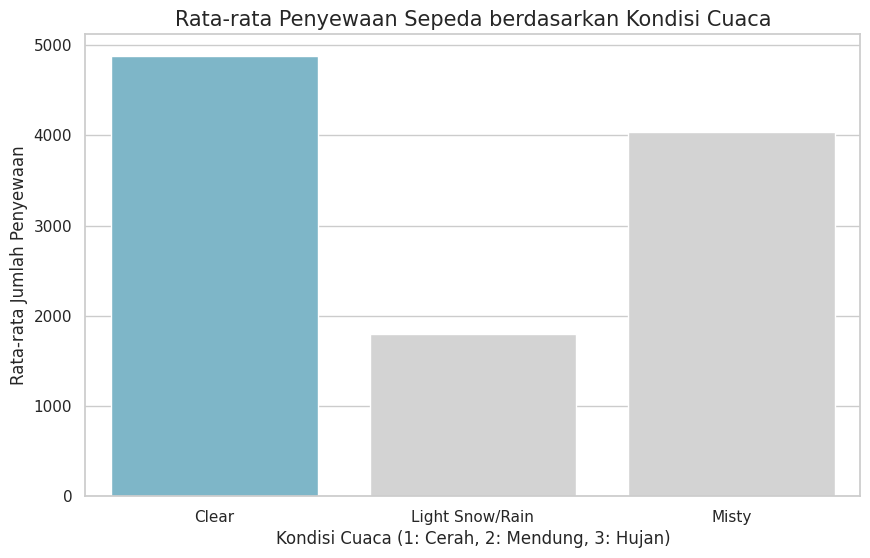

In [47]:
# Eksplorasi
weather_rentals = day_df.groupby(by="weathersit").cnt.mean().reset_index()

# Visualisasi
plt.figure(figsize=(10, 6))

colors = ["#D3D3D3"] * len(weather_rentals)
max_idx = weather_rentals['cnt'].idxmax()
colors[max_idx] = "#72BCD4" # Sorotan biru

sns.barplot(
    x='weathersit',
    y='cnt',
    data=weather_rentals,
    hue='weathersit',
    palette=colors,
    legend=False
)

plt.title('Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca', fontsize=15)
plt.xlabel('Kondisi Cuaca (1: Cerah, 2: Mendung, 3: Hujan)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.show()

### Pertanyaan 2:

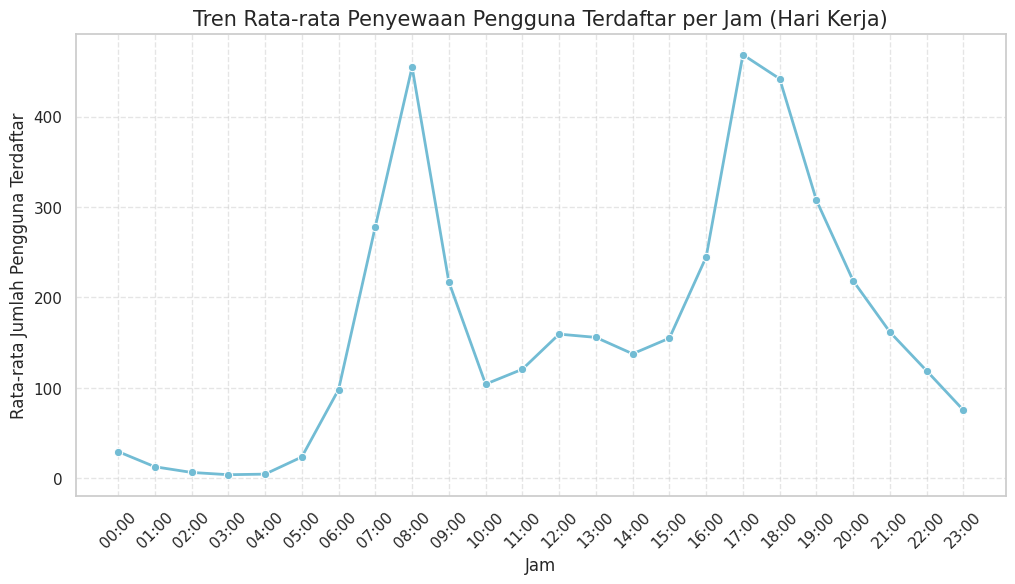

In [48]:
# Filter data hari kerja
workingday_df = hour_df[hour_df["workingday"] == 1]
hourly_registered = workingday_df.groupby(by="hr").registered.mean().reset_index()

# Visualisasi Garis
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='hr',
    y='registered',
    data=hourly_registered,
    marker='o',
    linewidth=2,
    color='#72BCD4'
)

# --- PERBAIKAN: Mengubah angka menjadi format jam ---
hours_label = [f"{int(x):02d}:00" for x in range(0, 24)]
plt.xticks(range(0, 24), hours_label, rotation=45)

plt.title('Tren Rata-rata Penyewaan Pengguna Terdaftar per Jam (Hari Kerja)', fontsize=15)
plt.xlabel('Jam', fontsize=12)
plt.ylabel('Rata-rata Jumlah Pengguna Terdaftar', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:** (Opsional)
- Dominasi Cuaca Cerah: Grafik batang menunjukkan perbedaan yang sangat kontras antara cuaca cerah (Clear) dengan kondisi lainnya. Penyewaan menurun drastis saat cuaca mulai mendung (Misty) dan mencapai titik terendah saat cuaca buruk (Light Rain/Snow). Hal ini menunjukkan bisnis sangat bergantung pada kondisi cuaca.

- Puncak Aktivitas Komuter: Berdasarkan grafik garis, terlihat dua puncak utama penyewaan oleh pengguna terdaftar pada hari kerja, yaitu pada pukul 08:00 pagi dan pukul 17:00-18:00 sore. Hal ini membuktikan bahwa mayoritas pengguna registered menggunakan sepeda sebagai alat transportasi utama untuk berangkat dan pulang kerja.

- Strategi Operasional: Dengan mengetahui pola jam sibuk ini, perusahaan dapat memastikan ketersediaan unit sepeda dan teknisi pemeliharaan pada stasiun-stasiun padat sebelum jam sibuk tersebut dimulai.

## Analisis Lanjutan (Opsional)

In [49]:
# --- ANALISIS LANJUTAN: Manual Grouping (Clustering) ---
def cluster_intensity(cnt):
    if cnt < 2000:
        return 'Low Demand'
    elif cnt < 5000:
        return 'Medium Demand'
    else:
        return 'High Demand'

# Menerapkan fungsi ke dataframe
day_df['demand_category'] = day_df['cnt'].apply(cluster_intensity)

# Mengatur urutan kategori agar logis saat divisualisasikan
category_order = ['Low Demand', 'Medium Demand', 'High Demand']
day_df['demand_category'] = pd.Categorical(day_df['demand_category'], categories=category_order, ordered=True)

# Melihat rata-rata suhu per kategori permintaan
demand_analysis = day_df.groupby('demand_category', observed=True).agg({
    'temp': 'mean',
    'cnt': 'count'
}).reset_index()

display(demand_analysis)

,demand_category,temp,cnt
0,Low Demand,0.270218,98
1,Medium Demand,0.485328,347
2,High Demand,0.584742,286


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kondisi cuaca berpengaruh signifikan terhadap minat penyewa sepeda. Cuaca cerah (Clear/Partly Cloudy) merupakan kondisi yang paling mendukung dengan rata-rata penyewaan tertinggi. Sebaliknya, terjadi penurunan drastis pada kondisi cuaca buruk seperti hujan atau salju ringan. Hal ini menunjukkan bahwa faktor kenyamanan cuaca adalah variabel utama dalam perilaku pengguna.
- **Conclusion pertanyaan 2:** Terdapat pola waktu yang sangat jelas pada penggunaan sepeda oleh pengguna terdaftar (registered) di hari kerja. Puncak penyewaan terjadi pada pukul 08.00 pagi dan antara pukul 17.00 - 18.00 sore. Pola ini mengonfirmasi bahwa mayoritas pengguna menggunakan layanan bike sharing sebagai sarana transportasi utama untuk komuter (berangkat dan pulang kantor/kampus).
- ...

**Rekomendasi Action Item:**
- Optimalisasi Stok & Pemeliharaan: Melakukan pengecekan rutin dan memastikan ketersediaan unit sepeda di stasiun-stasiun yang dekat dengan area perkantoran atau kampus sebelum jam sibuk pagi (08.00) dan sore (17.00).

- Promo Cuaca: Memberikan insentif atau promo khusus (seperti diskon atau poin tambahan) bagi pengguna yang tetap menggunakan sepeda saat cuaca mendung (Misty) guna menjaga angka penyewaan agar tidak turun terlalu tajam.

- Manajemen Inventaris Musiman: Menyiapkan unit sepeda tambahan dan meningkatkan kampanye pemasaran pada musim gugur dan panas, di mana permintaan sedang berada pada titik maksimal.